In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clean_df = pd.read_csv("../data/processed/clean_mandi_prices.csv")
clean_df['Price Date'] = pd.to_datetime(clean_df['Price Date'], format='%Y-%m-%d')

monthly_df = pd.read_csv("../data/processed/monthly_crop_prices.csv")
monthly_df['Date'] = pd.to_datetime(
    monthly_df['Year'].astype(str) + '-' +
    monthly_df['Month'].astype(str) + '-01'
)

print(clean_df.shape)
print(monthly_df.shape)
print(monthly_df.head())

(188080, 10)
(67, 5)
  Commodity  Year  Month  Avg_Modal_Price       Date
0     Onion  2023      6      1119.212229 2023-06-01
1     Onion  2023      7      1404.686554 2023-07-01
2     Onion  2023      8      1691.915848 2023-08-01
3     Onion  2023      9      1921.675517 2023-09-01
4     Onion  2023     10      2189.736582 2023-10-01


In [3]:
monthly_df['Year'] = monthly_df['Date'].dt.year
monthly_df['Month'] = monthly_df['Date'].dt.month
monthly_df['Quarter'] = monthly_df['Date'].dt.quarter

In [4]:
print(monthly_df[['Date', 'Year', 'Month', 'Quarter']].head(8))

        Date  Year  Month  Quarter
0 2023-06-01  2023      6        2
1 2023-07-01  2023      7        3
2 2023-08-01  2023      8        3
3 2023-09-01  2023      9        3
4 2023-10-01  2023     10        4
5 2023-11-01  2023     11        4
6 2023-12-01  2023     12        4
7 2024-01-01  2024      1        1


In [5]:
monthly_df = monthly_df.sort_values(['Commodity', 'Date']).reset_index(drop=True)

monthly_df['lag_1'] = monthly_df.groupby('Commodity')['Avg_Modal_Price'].shift(1)
monthly_df['lag_2'] = monthly_df.groupby('Commodity')['Avg_Modal_Price'].shift(2)
monthly_df['lag_3'] = monthly_df.groupby('Commodity')['Avg_Modal_Price'].shift(3)

In [6]:
print(monthly_df[['Commodity', 'Date', 'Avg_Modal_Price', 'lag_1', 'lag_2', 'lag_3']].head(10))

  Commodity       Date  Avg_Modal_Price        lag_1        lag_2        lag_3
0     Onion 2023-06-01      1119.212229          NaN          NaN          NaN
1     Onion 2023-07-01      1404.686554  1119.212229          NaN          NaN
2     Onion 2023-08-01      1691.915848  1404.686554  1119.212229          NaN
3     Onion 2023-09-01      1921.675517  1691.915848  1404.686554  1119.212229
4     Onion 2023-10-01      2189.736582  1921.675517  1691.915848  1404.686554
5     Onion 2023-11-01      3543.975133  2189.736582  1921.675517  1691.915848
6     Onion 2023-12-01      2737.284713  3543.975133  2189.736582  1921.675517
7     Onion 2024-01-01      1865.163121  2737.284713  3543.975133  2189.736582
8     Onion 2024-02-01      1559.834785  1865.163121  2737.284713  3543.975133
9     Onion 2024-03-01      1780.058879  1559.834785  1865.163121  2737.284713


In [9]:
print(monthly_df[monthly_df['Commodity'] == 'Potato'][
    ['Commodity', 'Date', 'Avg_Modal_Price', 'lag_1', 'lag_2', 'lag_3']].head(5))

   Commodity       Date  Avg_Modal_Price        lag_1        lag_2  \
24    Potato 2023-06-01       967.163562          NaN          NaN   
25    Potato 2023-07-01      1109.938275   967.163562          NaN   
26    Potato 2023-08-01      1137.635994  1109.938275   967.163562   
27    Potato 2023-09-01      1086.784160  1137.635994  1109.938275   
28    Potato 2023-10-01      1021.681831  1086.784160  1137.635994   

          lag_3  
24          NaN  
25          NaN  
26          NaN  
27   967.163562  
28  1109.938275  


In [10]:
monthly_df['rolling_mean_3'] = monthly_df.groupby('Commodity')['Avg_Modal_Price']\
    .transform(lambda x: x.shift(1).rolling(window=3).mean())

monthly_df['rolling_std_3'] = monthly_df.groupby('Commodity')['Avg_Modal_Price']\
    .transform(lambda x: x.shift(1).rolling(window=3).std())

In [11]:
print(monthly_df[['Commodity', 'Date', 'Avg_Modal_Price',
                   'rolling_mean_3', 'rolling_std_3']].head(10))

  Commodity       Date  Avg_Modal_Price  rolling_mean_3  rolling_std_3
0     Onion 2023-06-01      1119.212229             NaN            NaN
1     Onion 2023-07-01      1404.686554             NaN            NaN
2     Onion 2023-08-01      1691.915848             NaN            NaN
3     Onion 2023-09-01      1921.675517     1405.271543     286.352258
4     Onion 2023-10-01      2189.736582     1672.759306     259.026305
5     Onion 2023-11-01      3543.975133     1934.442649     249.155816
6     Onion 2023-12-01      2737.284713     2551.795744     869.643110
7     Onion 2024-01-01      1865.163121     2823.665476     681.239121
8     Onion 2024-02-01      1559.834785     2715.474322     839.618492
9     Onion 2024-03-01      1780.058879     2054.094206     611.038706


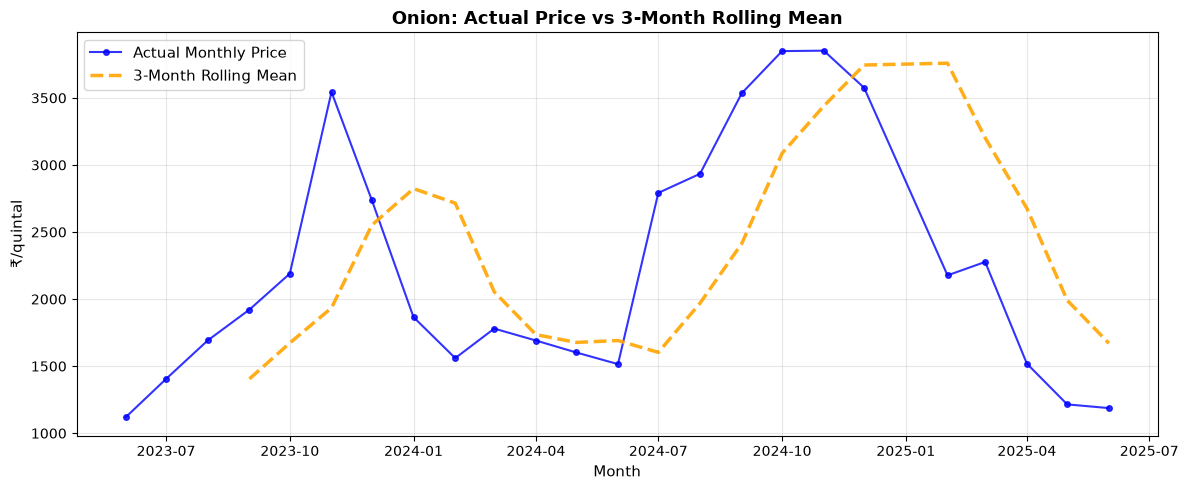

In [12]:
onion_data = monthly_df[monthly_df['Commodity'] == 'Onion'].sort_values('Date')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(onion_data['Date'], onion_data['Avg_Modal_Price'],
        color='blue', linewidth=1.5, marker='o', markersize=4,
        label='Actual Monthly Price', alpha=0.8)

ax.plot(onion_data['Date'], onion_data['rolling_mean_3'],
        color='orange', linewidth=2.5, linestyle='--',
        label='3-Month Rolling Mean', alpha=0.9)

ax.set_title('Onion: Actual Price vs 3-Month Rolling Mean',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('₹/quintal', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
onion_data = monthly_df[monthly_df['Commodity'] == 'Onion'].sort_values('Date').dropna()

print(f"Total Onion rows (after dropping NaN): {len(onion_data)}")
print(f"First date: {onion_data['Date'].min()}")
print(f"Last date: {onion_data['Date'].max()}")
print(f"\nSuggested split:")
print(f"Train: first 80% of dates")
print(f"Test: last 20% of dates")

split_idx = int(len(onion_data) * 0.8)
train_end_date = onion_data.iloc[split_idx - 1]['Date']
test_start_date = onion_data.iloc[split_idx]['Date']

print(f"\nTrain ends: {train_end_date.strftime('%Y-%m')}")
print(f"Test starts: {test_start_date.strftime('%Y-%m')}")
print(f"Train rows: {split_idx}, Test rows: {len(onion_data) - split_idx}")

Total Onion rows (after dropping NaN): 21
First date: 2023-09-01 00:00:00
Last date: 2025-06-01 00:00:00

Suggested split:
Train: first 80% of dates
Test: last 20% of dates

Train ends: 2024-12
Test starts: 2025-02
Train rows: 16, Test rows: 5


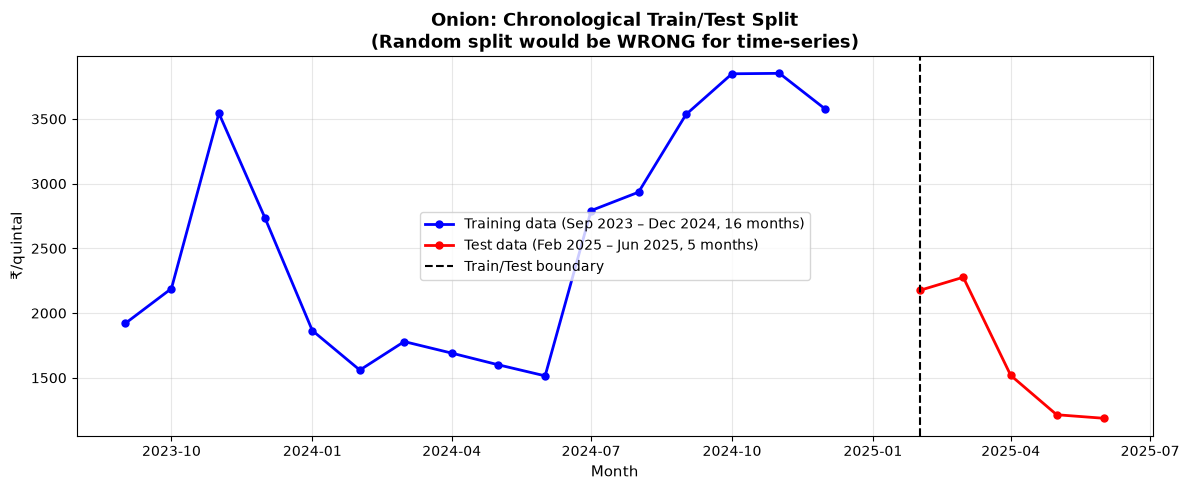

In [14]:
train_data = onion_data.iloc[:split_idx]
test_data = onion_data.iloc[split_idx:]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train_data['Date'], train_data['Avg_Modal_Price'],
        color='blue', linewidth=2, marker='o', markersize=5,
        label=f'Training data (Sep 2023 – Dec 2024, {len(train_data)} months)')

ax.plot(test_data['Date'], test_data['Avg_Modal_Price'],
        color='red', linewidth=2, marker='o', markersize=5,
        label=f'Test data (Feb 2025 – Jun 2025, {len(test_data)} months)')

ax.axvline(x=test_start_date, color='black', linestyle='--',
           linewidth=1.5, label='Train/Test boundary')

ax.set_title('Onion: Chronological Train/Test Split\n(Random split would be WRONG for time-series)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('₹/quintal', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
print(monthly_df.columns.tolist())
print(f"\nShape: {monthly_df.shape}")
print(f"\nFeatures per row:")
print(monthly_df.head(8))

['Commodity', 'Year', 'Month', 'Avg_Modal_Price', 'Date', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']

Shape: (67, 11)

Features per row:
  Commodity  Year  Month  Avg_Modal_Price       Date  Quarter        lag_1  \
0     Onion  2023      6      1119.212229 2023-06-01        2          NaN   
1     Onion  2023      7      1404.686554 2023-07-01        3  1119.212229   
2     Onion  2023      8      1691.915848 2023-08-01        3  1404.686554   
3     Onion  2023      9      1921.675517 2023-09-01        3  1691.915848   
4     Onion  2023     10      2189.736582 2023-10-01        4  1921.675517   
5     Onion  2023     11      3543.975133 2023-11-01        4  2189.736582   
6     Onion  2023     12      2737.284713 2023-12-01        4  3543.975133   
7     Onion  2024      1      1865.163121 2024-01-01        1  2737.284713   

         lag_2        lag_3  rolling_mean_3  rolling_std_3  
0          NaN          NaN             NaN            NaN  
1       

In [16]:
nan_summary = monthly_df.groupby('Commodity').apply(
    lambda x: x[['lag_1','lag_2','lag_3',
                  'rolling_mean_3','rolling_std_3']].isnull().sum()
)
print(nan_summary)

           lag_1  lag_2  lag_3  rolling_mean_3  rolling_std_3
Commodity                                                    
Onion          1      2      3               3              3
Potato         1      2      3               3              3
Rice           1      2      3               3              3
Tomato         1      2      3               3              3
Wheat          1      2      3               3              3


Rice has only 3 months of data (April-June 2025). After lag/rolling feature 
creation, all 3 rows have NaN values in lag_3, rolling_mean_3, and 
rolling_std_3 — leaving zero usable training rows. Rice will be excluded 
from the price prediction model. This is a direct consequence of the 
dataset's collection gap identified on Day 4.


In [17]:
usable = monthly_df.dropna(subset=['lag_1','lag_2','lag_3',
                                    'rolling_mean_3','rolling_std_3'])

print(usable.groupby('Commodity').size())
print(f"\nTotal usable rows: {len(usable)}")

Commodity
Onion     21
Potato    22
Tomato     3
Wheat      6
dtype: int64

Total usable rows: 52


In [18]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Save full feature-engineered dataset (includes NaN rows, all crops)
monthly_df.to_csv(
    "../data/processed/feature_engineered_prices.csv", index=False
)

# Save model-ready dataset (NaN dropped, Rice excluded automatically)
usable.to_csv(
    "../data/processed/model_ready_prices.csv", index=False
)

print("Saved successfully.")
print(f"feature_engineered_prices.csv: {monthly_df.shape}")
print(f"model_ready_prices.csv: {usable.shape}")

Saved successfully.
feature_engineered_prices.csv: (67, 11)
model_ready_prices.csv: (52, 11)


In [19]:
verify = pd.read_csv("../data/processed/model_ready_prices.csv")
print(verify.shape)
print(verify.columns.tolist())
print(verify.groupby('Commodity').size())
print(f"\nAny NaN values: {verify.isnull().sum().sum()}")

(52, 11)
['Commodity', 'Year', 'Month', 'Avg_Modal_Price', 'Date', 'Quarter', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']
Commodity
Onion     21
Potato    22
Tomato     3
Wheat      6
dtype: int64

Any NaN values: 0


## Day 6 Summary — Time-Series Feature Engineering

### Setup
Created notebook 05_feature_engineering.ipynb. Loaded clean_mandi_prices.csv 
and monthly_crop_prices.csv. Recreated Date column. Confirmed monthly_df 
has 67 rows × 5 columns before feature engineering.

### Part 1 — What feature engineering is
ML models perform mathematical operations on numbers — they cannot 
understand raw dates or categorical strings as meaningful inputs. 
Feature engineering transforms raw data into numeric columns that 
make patterns explicitly visible to a model. The difference between 
a good and bad ML model is almost always feature quality, not 
algorithm choice.

### Part 2 — Date features
Added: Year, Month, Quarter (Quarter was the only genuinely new column 
since Year/Month already existed).

- Year: captures long-term price trend (inflation, MSP increases)
- Month: captures seasonality (Onion peaks every November — model 
  learns this from Month=11)
- Quarter: coarser seasonality grouping — more data per category, 
  useful for crops with sparse monthly coverage

Key insight: Month is your most powerful feature for Onion (strong 
seasonal signal). Quarter is preferable for Tomato/Rice where monthly 
data is too sparse.

### Part 3 — Lag features
Created lag_1, lag_2, lag_3 using groupby('Commodity').shift() — 
critically, NOT a naive shift() on the full DataFrame, which would 
contaminate crop boundaries.

- lag_1 = last month's price (strongest single predictor)
- lag_2 = 2 months ago
- lag_3 = 3 months ago

Why they work: crop prices have inertia — current price is correlated 
with recent history. The direction of change across lag_3 → lag_2 → 
lag_1 is a momentum signal as important as the absolute values.

Why they fail: at the start of each crop's sequence (first 3 rows), 
lags are NaN. Also, if market structure changes suddenly (new government 
policy, extreme weather event), historical lags may not predict the 
new regime.

Key safety rule: ALWAYS use groupby().shift() for per-crop lag 
features — naive shift() silently creates cross-crop contamination 
with no error message.

### Part 4 — Rolling statistics
Created rolling_mean_3 and rolling_std_3 using groupby + transform + 
shift(1).rolling(3).

- rolling_mean_3: average of last 3 months before current month — 
  smooths noise, reveals underlying trend direction
- rolling_std_3: std dev of last 3 months — captures whether market 
  is currently stable or turbulent

Critical detail: shift(1) BEFORE rolling() prevents data leakage — 
without it, the current month's price would be included in its own 
rolling average (using the answer as an input).

Visualized actual price vs rolling mean for Onion — confirmed the 
rolling mean consistently lags the actual price by 2-3 months 
(backward-looking by design). The gap between rolling_mean and lag_1 
functions as a momentum signal: large positive gap = price above 
recent trend = potential mean reversion; large negative gap = price 
below trend = potential recovery.

### Part 5 — Time-series train/test split
Chronological split (80/20 by row position, NOT random shuffle).

For Onion: 16 training rows (Sep 2023 – Dec 2024), 5 test rows 
(Feb 2025 – Jun 2025).

Why random split is WRONG: lag features for a test row may have been 
computed using rows that ended up in the training set — meaning the 
model "sees the future" during training, producing falsely optimistic 
evaluation results. Chronological split ensures the model genuinely 
predicts an unseen future.

Interview answer: "In time-series, rows are connected through lag 
features — random splitting leaks future information into training. 
Chronological split ensures the model predicts genuinely unseen 
future dates."

### Part 6 — Feature inspection
NaN counts per crop after feature engineering:
- lag_1: 1 NaN per crop (first row has no prior month)
- lag_2: 2 NaN per crop
- lag_3: 3 NaN per crop (also rolling features)

Rice: ALL 3 rows have NaN in lag_3/rolling features → 0 usable rows 
→ excluded from modeling.

Usable rows after dropna():
- Onion: 21, Potato: 22, Wheat: 6, Tomato: 3, Rice: 0
- Total: 52 usable rows

Modeling scope decision: core price prediction models will focus on 
Onion and Potato (adequate data for reliable training/validation). 
Wheat and Tomato will be included as supplementary models with 
explicitly documented caveats about limited training data.

### Part 7 — Files saved
- data/processed/feature_engineered_prices.csv (67 rows × 11 cols, 
  includes NaN rows — full audit trail)
- data/processed/model_ready_prices.csv (52 rows × 11 cols, 
  NaN dropped — ready for Day 8 model training)

### Key concepts mastered today
1. Feature engineering = translating patterns into model-readable numbers
2. groupby().shift() is mandatory for per-crop lag features
3. shift(1) before rolling() prevents data leakage in rolling features
4. Chronological train/test split is non-negotiable for time-series
5. NaN creation from lag/rolling is expected and correct — not a bug
6. Dataset limitations (Rice: 0 usable rows) are findings, not failures